In [1]:
import pandas as pd

In [2]:
df1 = pd.read_csv("../data/annex1.csv")

df1.head()

,Item Code,Item Name,Category Code,Category Name
0,102900005115168,Niushou Shengcai,1011010101,Flower/Leaf Vegetables
1,102900005115199,Sichuan Red Cedar,1011010101,Flower/Leaf Vegetables
2,102900005115625,Local Xiaomao Cabbage,1011010101,Flower/Leaf Vegetables
3,102900005115748,White Caitai,1011010101,Flower/Leaf Vegetables
4,102900005115762,Amaranth,1011010101,Flower/Leaf Vegetables


In [3]:
df1.head()

,Item Code,Item Name,Category Code,Category Name
0,102900005115168,Niushou Shengcai,1011010101,Flower/Leaf Vegetables
1,102900005115199,Sichuan Red Cedar,1011010101,Flower/Leaf Vegetables
2,102900005115625,Local Xiaomao Cabbage,1011010101,Flower/Leaf Vegetables
3,102900005115748,White Caitai,1011010101,Flower/Leaf Vegetables
4,102900005115762,Amaranth,1011010101,Flower/Leaf Vegetables


In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Item Code      251 non-null    int64
 1   Item Name      251 non-null    str  
 2   Category Code  251 non-null    int64
 3   Category Name  251 non-null    str  
dtypes: int64(2), str(2)
memory usage: 16.8 KB


In [5]:
df2 = pd.read_csv("../data/annex2.csv")

df2.head()


,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No)
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,sale,No
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,sale,No


In [6]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 7 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Date                         878503 non-null  str    
 1   Time                         878503 non-null  str    
 2   Item Code                    878503 non-null  int64  
 3   Quantity Sold (kilo)         878503 non-null  float64
 4   Unit Selling Price (RMB/kg)  878503 non-null  float64
 5   Sale or Return               878503 non-null  str    
 6   Discount (Yes/No)            878503 non-null  str    
dtypes: float64(2), int64(1), str(4)
memory usage: 70.4 MB


In [7]:
df3 = pd.read_csv("../data/annex3.csv")

df3.head()

,Date,Item Code,Wholesale Price (RMB/kg)
0,2020-07-01,102900005115762,3.88
1,2020-07-01,102900005115779,6.72
2,2020-07-01,102900005115786,3.19
3,2020-07-01,102900005115793,9.24
4,2020-07-01,102900005115823,7.03


In [8]:
df4 = pd.read_csv("../data/annex4.csv")

df4.head()

,Item Code,Item Name,Loss Rate (%)
0,102900005115168,Niushou Shengcai,4.39
1,102900005115199,Sichuan Red Cedar,10.46
2,102900005115250,Xixia Black Mushroom (1),10.80
3,102900005115625,Local Xiaomao Cabbage,0.18
4,102900005115748,White Caitai,8.78


In [9]:
print("annex1:", df1.shape)
print("annex2:", df2.shape)
print("annex3:", df3.shape)
print("annex4:", df4.shape)

annex1: (251, 4)
annex2: (878503, 7)
annex3: (55982, 3)
annex4: (251, 3)


In [10]:
products = pd.merge(
    df1,
    df4[["Item Code", "Loss Rate (%)"]],
    on="Item Code",
    how="left"
)

products.head()

,Item Code,Item Name,Category Code,Category Name,Loss Rate (%)
0,102900005115168,Niushou Shengcai,1011010101,Flower/Leaf Vegetables,4.39
1,102900005115199,Sichuan Red Cedar,1011010101,Flower/Leaf Vegetables,10.46
2,102900005115625,Local Xiaomao Cabbage,1011010101,Flower/Leaf Vegetables,0.18
3,102900005115748,White Caitai,1011010101,Flower/Leaf Vegetables,8.78
4,102900005115762,Amaranth,1011010101,Flower/Leaf Vegetables,18.52


In [11]:
products.shape

(251, 5)

In [12]:
sales = pd.merge(
    df2,
    products,
    on="Item Code",
    how="left"
)

sales.head()

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No),Item Name,Category Code,Category Name,Loss Rate (%)
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No,Chinese Cabbage,1011010101,Flower/Leaf Vegetables,22.27
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,sale,No,Shanghaiqing,1011010101,Flower/Leaf Vegetables,14.43
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,sale,No,Caixin,1011010101,Flower/Leaf Vegetables,13.70


In [13]:
sales.shape

(878503, 11)

In [14]:
sales["Date"] = pd.to_datetime(sales["Date"])
df3["Date"] = pd.to_datetime(df3["Date"])

final_df = pd.merge(
    sales,
    df3,
    on=["Date", "Item Code"],
    how="left"
)

final_df.head()

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No),Item Name,Category Code,Category Name,Loss Rate (%),Wholesale Price (RMB/kg)
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08,4.32
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No,Chinese Cabbage,1011010101,Flower/Leaf Vegetables,22.27,2.10
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08,4.32
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,sale,No,Shanghaiqing,1011010101,Flower/Leaf Vegetables,14.43,7.03
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,sale,No,Caixin,1011010101,Flower/Leaf Vegetables,13.70,4.60


In [15]:
final_df.shape

(878503, 12)

In [16]:
final_df.isnull().sum()

Date                           0
Time                           0
Item Code                      0
Quantity Sold (kilo)           0
Unit Selling Price (RMB/kg)    0
Sale or Return                 0
Discount (Yes/No)              0
Item Name                      0
Category Code                  0
Category Name                  0
Loss Rate (%)                  0
Wholesale Price (RMB/kg)       0
dtype: int64

In [17]:
final_df["Total_Sales"] = (
    final_df["Quantity Sold (kilo)"]
    * final_df["Unit Selling Price (RMB/kg)"]
)

final_df.head()

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Sale or Return,Discount (Yes/No),Item Name,Category Code,Category Name,Loss Rate (%),Wholesale Price (RMB/kg),Total_Sales
0,2020-07-01,09:15:07.924,102900005117056,0.396,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08,4.32,3.0096
1,2020-07-01,09:17:27.295,102900005115960,0.849,3.2,sale,No,Chinese Cabbage,1011010101,Flower/Leaf Vegetables,22.27,2.10,2.7168
2,2020-07-01,09:17:33.905,102900005117056,0.409,7.6,sale,No,Paopaojiao (Jingpin),1011010504,Capsicum,7.08,4.32,3.1084
3,2020-07-01,09:19:45.450,102900005115823,0.421,10.0,sale,No,Shanghaiqing,1011010101,Flower/Leaf Vegetables,14.43,7.03,4.2100
4,2020-07-01,09:20:23.686,102900005115908,0.539,8.0,sale,No,Caixin,1011010101,Flower/Leaf Vegetables,13.70,4.60,4.3120


In [18]:
final_df["Total_Sales"].describe()

count    878503.000000
mean          3.835805
std           2.813984
min        -100.000000
25%           2.210000
50%           3.332000
75%           4.791600
max         944.000000
Name: Total_Sales, dtype: float64

In [19]:
final_df["Date"] = pd.to_datetime(final_df["Date"])

final_df["Month"] = final_df["Date"].dt.month
final_df["Day"] = final_df["Date"].dt.day
final_df["Weekday"] = final_df["Date"].dt.day_name()

In [20]:
final_df["Hour"] = pd.to_datetime(
    final_df["Time"],
    format="%H:%M:%S.%f",
    errors="coerce"
).dt.hour

final_df[["Time", "Hour"]].head()

,Time,Hour
0,09:15:07.924,9.0
1,09:17:27.295,9.0
2,09:17:33.905,9.0
3,09:19:45.450,9.0
4,09:20:23.686,9.0


In [21]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 878503 entries, 0 to 878502
Data columns (total 17 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   Date                         878503 non-null  datetime64[us]
 1   Time                         878503 non-null  str           
 2   Item Code                    878503 non-null  int64         
 3   Quantity Sold (kilo)         878503 non-null  float64       
 4   Unit Selling Price (RMB/kg)  878503 non-null  float64       
 5   Sale or Return               878503 non-null  str           
 6   Discount (Yes/No)            878503 non-null  str           
 7   Item Name                    878503 non-null  str           
 8   Category Code                878503 non-null  int64         
 9   Category Name                878503 non-null  str           
 10  Loss Rate (%)                878503 non-null  float64       
 11  Wholesale Price (RMB/kg)     878503 n

In [22]:
final_df.shape

(878503, 17)

In [23]:
final_df.to_csv("../data/final_supermarket_sales.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


In [24]:
import os

os.listdir("../data")

['annex1.csv',
 'annex2.csv',
 'annex3.csv',
 'annex4.csv',
 'final_supermarket_sales.csv']

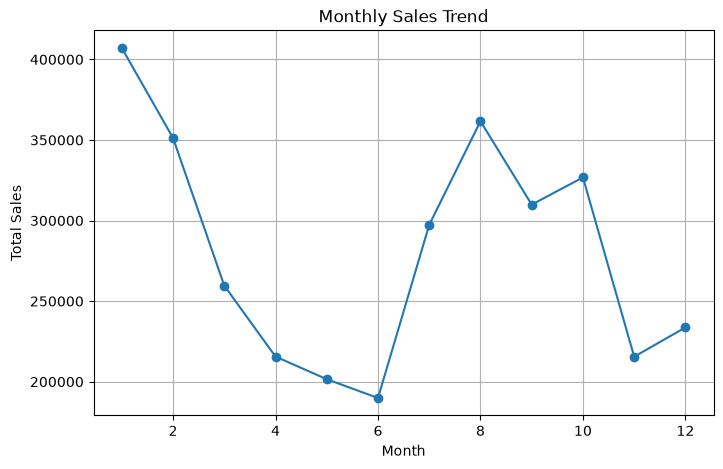

In [25]:
import matplotlib.pyplot as plt

monthly_sales = final_df.groupby("Month")["Total_Sales"].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

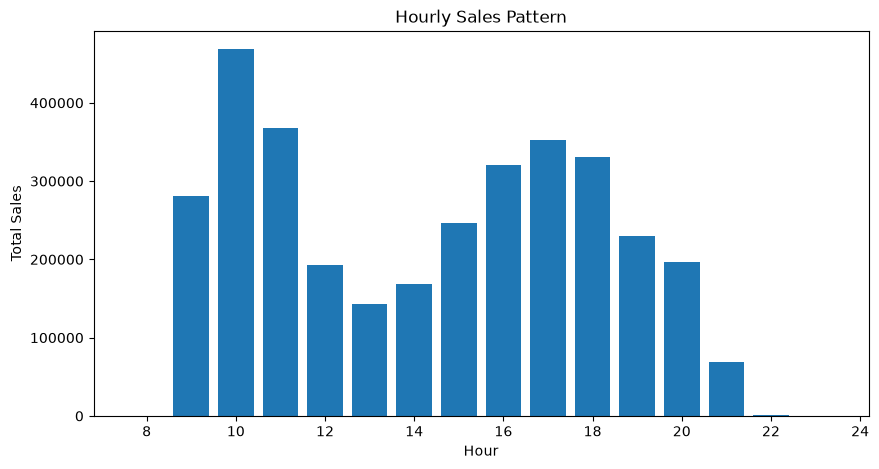

In [26]:
hourly_sales = final_df.groupby("Hour")["Total_Sales"].sum()

plt.figure(figsize=(10,5))
plt.bar(hourly_sales.index, hourly_sales.values)

plt.title("Hourly Sales Pattern")
plt.xlabel("Hour")
plt.ylabel("Total Sales")

plt.show()

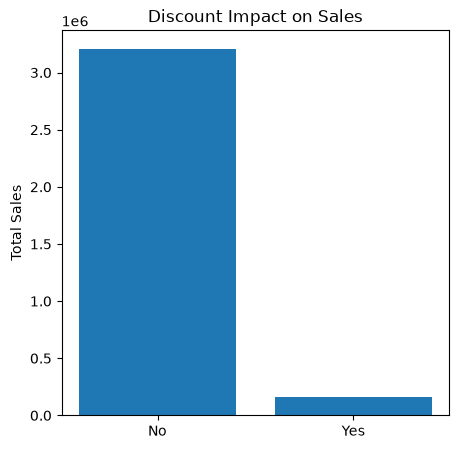

In [27]:
discount_sales = final_df.groupby("Discount (Yes/No)")["Total_Sales"].sum()

plt.figure(figsize=(5,5))
plt.bar(discount_sales.index, discount_sales.values)

plt.title("Discount Impact on Sales")
plt.ylabel("Total Sales")

plt.show()

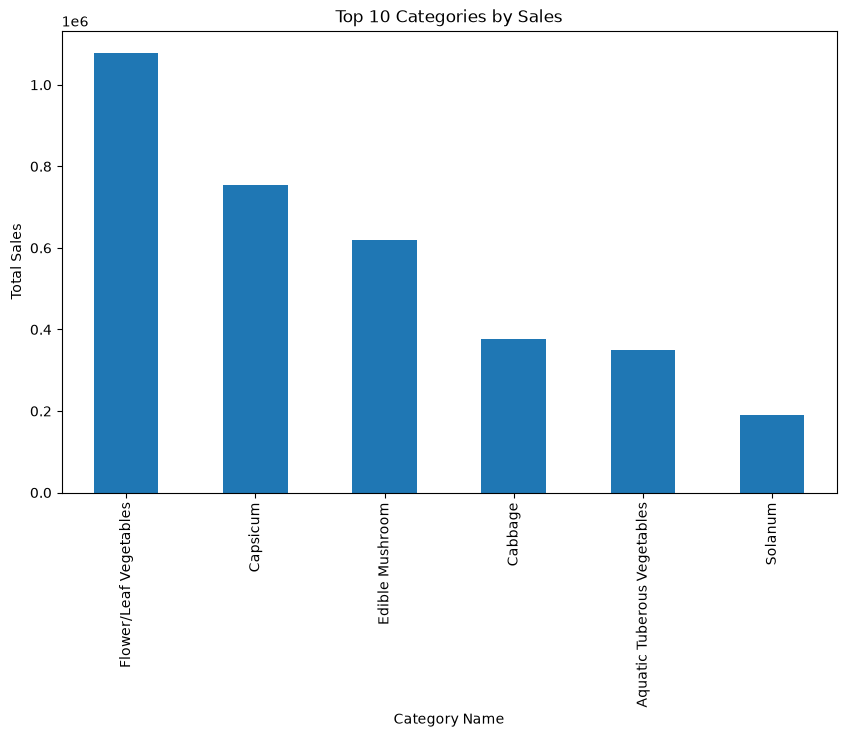

In [28]:
top_categories = (
    final_df.groupby("Category Name")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_categories.plot(kind="bar")

plt.title("Top 10 Categories by Sales")
plt.ylabel("Total Sales")

plt.show()

In [29]:
top_products = (
    final_df.groupby("Item Name")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products


Item Name
Broccoli                 269880.9572
Net Lotus Root (1)       211652.1013
Xixia Mushroom (1)       211198.3864
Wuhu Green Pepper (1)    205113.6991
Yunnan Shengcai          129756.9615
Eggplant (2)             117729.4239
Paopaojiao (Jingpin)      95568.6339
Luosi Pepper              82009.3451
Yunnan Lettuces           70665.1061
Chinese Cabbage           65675.4366
Name: Total_Sales, dtype: float64

In [30]:
top_categories = (
    final_df.groupby("Category Name")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

top_categories.head(10)

Category Name
Flower/Leaf Vegetables         1.079070e+06
Capsicum                       7.541330e+05
Edible Mushroom                6.195978e+05
Cabbage                        3.757517e+05
Aquatic Tuberous Vegetables    3.500899e+05
Solanum                        1.911243e+05
Name: Total_Sales, dtype: float64

In [31]:
final_df.describe()

,Date,Item Code,Quantity Sold (kilo),Unit Selling Price (RMB/kg),Category Code,Loss Rate (%),Wholesale Price (RMB/kg),Total_Sales,Month,Day,Hour
count,878503,8.785030e+05,878503.000000,878503.000000,8.785030e+05,878503.000000,878503.000000,878503.000000,878503.000000,878503.000000,878371.000000
mean,2021-11-20 20:11:55.407915,1.030313e+14,0.536112,8.917144,1.011010e+09,10.122526,5.663150,3.835805,6.573912,15.631037,14.408697
min,2020-07-01 00:00:00,1.029000e+14,-9.082000,0.100000,1.011010e+09,0.000000,0.010000,-100.000000,1.000000,1.000000,8.000000
25%,2021-02-06 00:00:00,1.029000e+14,0.290000,4.900000,1.011010e+09,6.270000,3.000000,2.210000,3.000000,8.000000,11.000000
50%,2021-10-11 00:00:00,1.029000e+14,0.435000,7.900000,1.011010e+09,9.430000,4.690000,3.332000,7.000000,16.000000,15.000000
75%,2022-09-10 00:00:00,1.029000e+14,0.742000,10.800000,1.011011e+09,13.620000,7.010000,4.791600,9.000000,23.000000,18.000000
max,2023-06-30 00:00:00,1.069740e+14,160.000000,119.900000,1.011011e+09,29.250000,141.000000,944.000000,12.000000,31.000000,23.000000
std,NaN,7.174368e+11,0.400087,6.311265,2.582929e+02,4.741439,4.229638,2.813984,3.440707,8.751631,3.666504
